# CowVision: AI Training Pipeline
## Deteksi Penyakit Mastitis pada Sapi Perah Berbasis Dual-Modality (XGBoost & CNN)

Notebook ini menyediakan pipeline lengkap pelatihan Artificial Intelligence untuk sistem **CowVision** menggunakan dua dataset:
1. **Dataset Susu (Tabular)**: Menggunakan algoritma **XGBoost Classifier** untuk mendeteksi mastitis dari parameter fisikokimia susu (*Somatic Cell Count / SCC*, suhu, pH, konduktivitas listrik, hasil perahan, dan penggumpalan).
2. **Dataset Citra Ambing (Visual)**: Menggunakan algoritma **Convolutional Neural Network (CNN)** dengan *Transfer Learning (MobileNetV2)* dan *Aggressive Data Augmentation* untuk mendeteksi gejala visual mastitis pada ambing & puting sapi (kemerahan, pembengkakan, hiperkeratosis).

---

### 1. Inisialisasi Environment & Import Library

In [1]:
import os
import glob
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Machine Learning & XGBoost
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier
import joblib

# Deep Learning & PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

# Konfigurasi Device & Path
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device komputasi: {DEVICE}")

BASE_DIR = os.getcwd()
MILK_CSV_PATH = os.path.join(BASE_DIR, "Dataset", "Susu", "cow_milk_mastitis_dataset.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "Dataset", "Gambar", "Data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
REPORT_DIR = os.path.join(BASE_DIR, "reports")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
print("Direktori models dan reports siap!")

Device komputasi: cpu
Direktori models dan reports siap!


--- 
## BAGIAN 1: MODEL XGBOOST (DATASET PARAMETER SUSU)

Tahap ini mengolah data sensorik susu sapi perah untuk mengklasifikasikan kondisi sapi (`class1`: 0 = Normal / Sehat, 1 = Mastitis).

#### 1.1 Eksplorasi Data (EDA) & Pengecekan Missing Value

In [2]:
df_milk = pd.read_csv(MILK_CSV_PATH)
print(f"Dimensi Dataset Susu: {df_milk.shape[0]} baris x {df_milk.shape[1]} kolom")
display(df_milk.head())

print("\nPengecekan Nilai Kosong (Missing Values):")
print(df_milk.isnull().sum())

print("\nDistribusi Target (class1):")
class_counts = df_milk['class1'].value_counts()
print(class_counts)
print(f"Persentase Mastitis: {class_counts[1] / len(df_milk) * 100:.2f}%")

Dimensi Dataset Susu: 800 baris x 9 kolom


,Cow_ID,Day,Milk_Temperature,Milk_pH,Milk_Conductivity,Somatic_Cell_Count,Milk_Yield,Clotting,class1
0,C0001,7,35.38,6.49,4.68,148,17.3,0,0
1,C0002,20,35.68,6.46,5.04,101,20.4,0,0
2,C0003,29,34.87,6.84,4.73,206,18.5,0,0
3,C0004,15,36.22,6.69,4.48,96,23.5,0,0
4,C0005,11,35.46,6.56,5.00,142,23.9,0,0



Pengecekan Nilai Kosong (Missing Values):
Cow_ID                0
Day                   0
Milk_Temperature      0
Milk_pH               0
Milk_Conductivity     0
Somatic_Cell_Count    0
Milk_Yield            0
Clotting              0
class1                0
dtype: int64

Distribusi Target (class1):
class1
0    631
1    169
Name: count, dtype: int64
Persentase Mastitis: 21.12%


#### 1.2 Visualisasi Korelasi Parameter Susu dengan Kejadian Mastitis

C:\Users\ryuxy\AppData\Local\Temp\ipykernel_14640\1314941269.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class1', y='Somatic_Cell_Count', data=df_milk, palette=['#4CAF50', '#E53935'])
C:\Users\ryuxy\AppData\Local\Temp\ipykernel_14640\1314941269.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class1', y='Milk_Temperature', data=df_milk, palette=['#4CAF50', '#E53935'])
C:\Users\ryuxy\AppData\Local\Temp\ipykernel_14640\1314941269.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class1', y='Milk_Conductivity', data=df_m

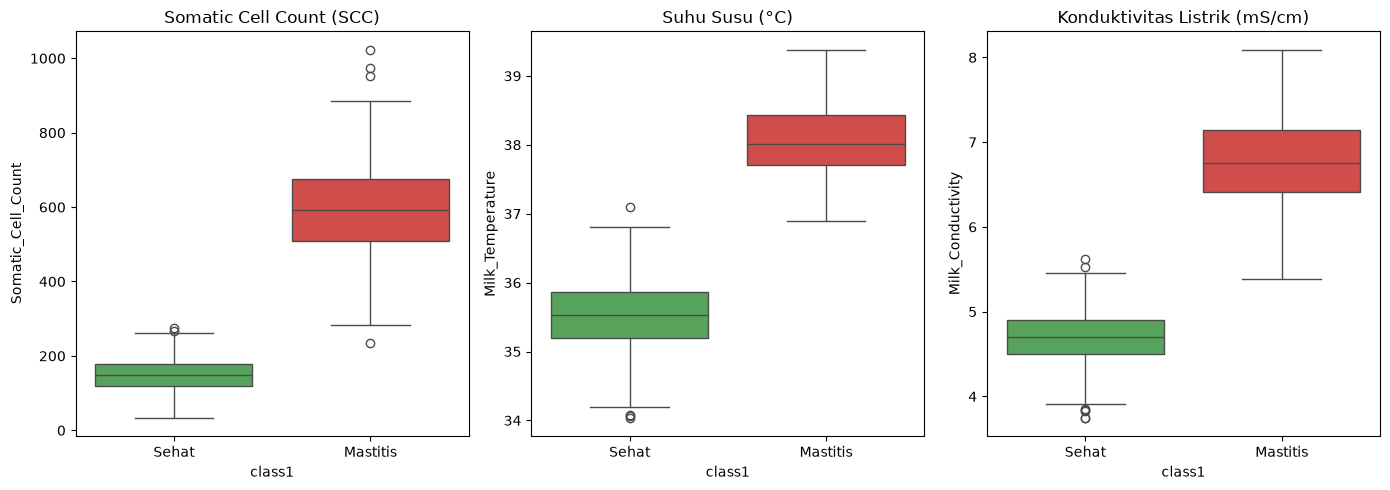

In [3]:
plt.figure(figsize=(14, 5))

# 1. Somatic Cell Count vs Class
plt.subplot(1, 3, 1)
sns.boxplot(x='class1', y='Somatic_Cell_Count', data=df_milk, palette=['#4CAF50', '#E53935'])
plt.title('Somatic Cell Count (SCC)')
plt.xticks([0, 1], ['Sehat', 'Mastitis'])

# 2. Suhu Susu vs Class
plt.subplot(1, 3, 2)
sns.boxplot(x='class1', y='Milk_Temperature', data=df_milk, palette=['#4CAF50', '#E53935'])
plt.title('Suhu Susu (°C)')
plt.xticks([0, 1], ['Sehat', 'Mastitis'])

# 3. Konduktivitas Susu vs Class
plt.subplot(1, 3, 3)
sns.boxplot(x='class1', y='Milk_Conductivity', data=df_milk, palette=['#4CAF50', '#E53935'])
plt.title('Konduktivitas Listrik (mS/cm)')
plt.xticks([0, 1], ['Sehat', 'Mastitis'])

plt.tight_layout()
plt.show()

#### 1.3 Pembagian Data Latih & Uji (Stratified Split)

In [4]:
features = ["Day", "Milk_Temperature", "Milk_pH", "Milk_Conductivity", "Somatic_Cell_Count", "Milk_Yield", "Clotting"]
X = df_milk[features]
y = df_milk["class1"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Data Latih : {X_train.shape[0]} sampel")
print(f"Data Uji   : {X_test.shape[0]} sampel")
print(f"Rasio Bobot Kelas (scale_pos_weight) = {scale_pos_weight:.2f}")

Data Latih : 640 sampel
Data Uji   : 160 sampel
Rasio Bobot Kelas (scale_pos_weight) = 3.74


#### 1.4 Pelatihan Model XGBoost Classifier

In [5]:
xgb_model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("Model XGBoost Berhasil Dilatih!")

Model XGBoost Berhasil Dilatih!


#### 1.5 Evaluasi Performa Model XGBoost

=== METRIK EVALUASI XGBOOST ===
Akurasi   : 98.75%
Presisi   : 100.00%
Recall    : 94.12%
F1-Score  : 96.97%
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

       Sehat       0.98      1.00      0.99       126
    Mastitis       1.00      0.94      0.97        34

    accuracy                           0.99       160
   macro avg       0.99      0.97      0.98       160
weighted avg       0.99      0.99      0.99       160



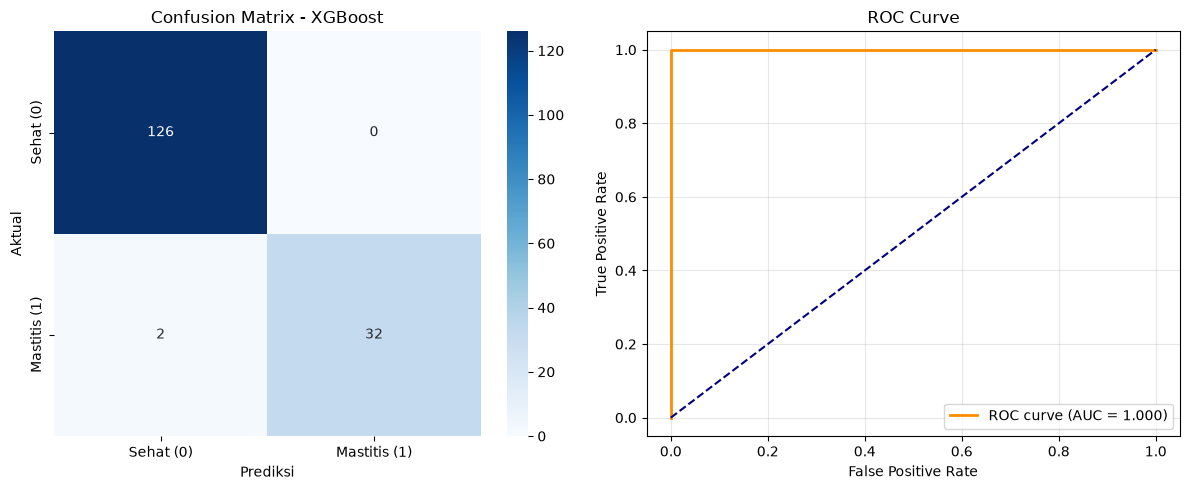

In [6]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== METRIK EVALUASI XGBOOST ===")
print(f"Akurasi   : {acc * 100:.2f}%")
print(f"Presisi   : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Sehat", "Mastitis"]))

# Visualisasi Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sehat (0)', 'Mastitis (1)'], yticklabels=['Sehat (0)', 'Mastitis (1)'])
axes[0].set_title('Confusion Matrix - XGBoost')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 1.6 Analisis Feature Importance (Faktor Paling Berpengaruh)

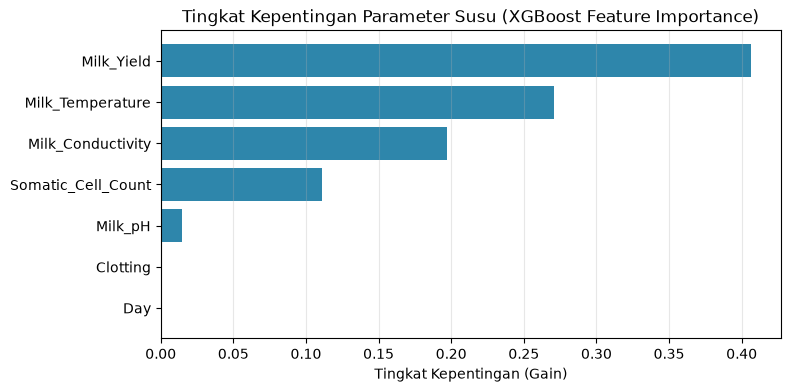

In [7]:
importance = xgb_model.feature_importances_
feat_df = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='#2E86AB')
plt.title('Tingkat Kepentingan Parameter Susu (XGBoost Feature Importance)')
plt.xlabel('Tingkat Kepentingan (Gain)')
plt.grid(axis='x', alpha=0.3)
plt.show()

#### 1.7 Menyimpan Model XGBoost

In [8]:
xgb_json_path = os.path.join(MODEL_DIR, "xgboost_milk_model.json")
xgb_joblib_path = os.path.join(MODEL_DIR, "xgboost_milk_model.joblib")

xgb_model.save_model(xgb_json_path)
joblib.dump({"model": xgb_model, "feature_names": features}, xgb_joblib_path)
print(f"Model tersimpan di:\n- {xgb_json_path}\n- {xgb_joblib_path}")

Model tersimpan di:
- c:\Users\ryuxy\PPL-AGRO\AI\models\xgboost_milk_model.json
- c:\Users\ryuxy\PPL-AGRO\AI\models\xgboost_milk_model.joblib


--- 
## BAGIAN 2: MODEL CNN (DATASET CITRA AMBING & PUTING SAPI)

Tahap ini melatih jaringan saraf konvolusi (CNN) untuk mendeteksi tanda peradangan eksternal pada ambing sapi menggunakan transfer learning arsitektur **MobileNetV2**.

#### 2.1 Pindaian Dataset Citra & Pengecekan Ketidakseimbangan Sampel

In [9]:
CLASS_NAMES = ["Normal", "Mastitis"]
LABEL_MAP = {"normal teats": 0, "normal": 0, "mastitis": 1}
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_paths = []
labels = []

for folder_name, lbl in LABEL_MAP.items():
    fpath = os.path.join(IMAGE_DIR, folder_name)
    if os.path.exists(fpath):
        for fname in os.listdir(fpath):
            if fname.lower().endswith(valid_exts):
                image_paths.append(os.path.join(fpath, fname))
                labels.append(lbl)

labels = np.array(labels)
print(f"Total Citra Ditemukan: {len(image_paths)}")
print(f"Normal   : {(labels == 0).sum()} citra")
print(f"Mastitis : {(labels == 1).sum()} citra")
print("CATATAN: Terdapat ketidakseimbangan kelas signifikan, sistem akan menggunakan Weighted Cross Entropy & Random Augmentation.")

Total Citra Ditemukan: 180
Normal   : 10 citra
Mastitis : 170 citra
CATATAN: Terdapat ketidakseimbangan kelas signifikan, sistem akan menggunakan Weighted Cross Entropy & Random Augmentation.


#### 2.2 Visualisasi Sampel Citra Ambing

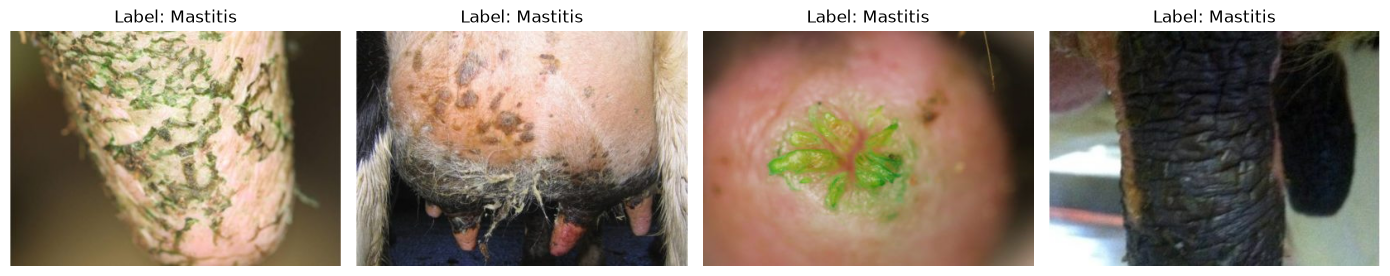

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
sample_indices = np.random.choice(len(image_paths), 4, replace=False)

for i, idx in enumerate(sample_indices):
    img = Image.open(image_paths[idx])
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {CLASS_NAMES[labels[idx]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### 2.3 Data Loader & Augmentasi Citra

In [11]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.20, random_state=42, stratify=labels
)

# Transformasi & Augmentasi data
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class TeatDataset(Dataset):
    def __init__(self, paths, lbls, transform=None):
        self.paths = paths
        self.lbls = lbls
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.lbls[idx], dtype=torch.long)

train_dataset = TeatDataset(train_paths, train_labels, transform=train_transform)
val_dataset = TeatDataset(val_paths, val_labels, transform=val_transform)

# Weighted Random Sampler untuk menangani kelas minoritas
class_counts = np.bincount(train_labels)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
print(f"Data Loader Siap! (Train: {len(train_dataset)}, Val: {len(val_dataset)})")

Data Loader Siap! (Train: 144, Val: 36)


#### 2.4 Membangun Arsitektur CNN (MobileNetV2 Transfer Learning)

In [12]:
cnn_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Ganti Head Classifier untuk 2 kelas (Normal vs Mastitis)
in_feat = cnn_model.classifier[1].in_features
cnn_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_feat, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 2)
)
cnn_model = cnn_model.to(DEVICE)

# Bobot loss untuk menangani imbalance
w = torch.tensor([class_weights[0], class_weights[1]], dtype=torch.float).to(DEVICE)
w = w / w.sum()
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = optim.AdamW(cnn_model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print("Model CNN & Optimizer siap dilatih!")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\ryuxy/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 7.60MB/s]

Model CNN & Optimizer siap dilatih!


#### 2.5 Pelatihan Model CNN

In [13]:
EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_weights = copy.deepcopy(cnn_model.state_dict())
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    # Training Phase
    cnn_model.train()
    train_loss, train_correct = 0.0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = cnn_model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == lbls).sum().item()
        
    # Validation Phase
    cnn_model.eval()
    val_loss, val_correct = 0.0, 0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = cnn_model(imgs)
            loss = criterion(outputs, lbls)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == lbls).sum().item()
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(lbls.cpu().numpy())
            
    tr_loss = train_loss / len(train_dataset)
    tr_acc = train_correct / len(train_dataset)
    v_loss = val_loss / len(val_dataset)
    v_acc = val_correct / len(val_dataset)
    v_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
    
    scheduler.step(v_loss)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(v_acc)
    
    print(f"Epoch [{epoch:02d}/{EPOCHS}] Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.1f}% | Val Loss: {v_loss:.4f} | Val Acc: {v_acc*100:.1f}% | Macro F1: {v_f1:.3f}")
    
    if v_f1 >= best_val_f1:
        best_val_f1 = v_f1
        best_weights = copy.deepcopy(cnn_model.state_dict())

cnn_model.load_state_dict(best_weights)
print("Pelatihan CNN Selesai! Bobot optimal dimuat.")

Epoch [01/15] Train Loss: 0.5865 | Train Acc: 50.0% | Val Loss: 0.7413 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [02/15] Train Loss: 0.3609 | Train Acc: 54.9% | Val Loss: 0.8153 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [03/15] Train Loss: 0.2400 | Train Acc: 47.9% | Val Loss: 0.9196 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [04/15] Train Loss: 0.1476 | Train Acc: 52.8% | Val Loss: 0.9504 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [05/15] Train Loss: 0.1543 | Train Acc: 44.4% | Val Loss: 0.9452 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [06/15] Train Loss: 0.1042 | Train Acc: 52.1% | Val Loss: 0.8848 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [07/15] Train Loss: 0.0899 | Train Acc: 53.5% | Val Loss: 0.8709 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [08/15] Train Loss: 0.0806 | Train Acc: 56.2% | Val Loss: 0.8151 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [09/15] Train Loss: 0.0729 | Train Acc: 55.6% | Val Loss: 0.8095 | Val Acc: 5.6% | Macro F1: 0.053
Epoch [10/15] Train Loss: 0.0917 | Train Acc: 55.6% | V

#### 2.6 Evaluasi & Visualisasi Kurva Belajar CNN

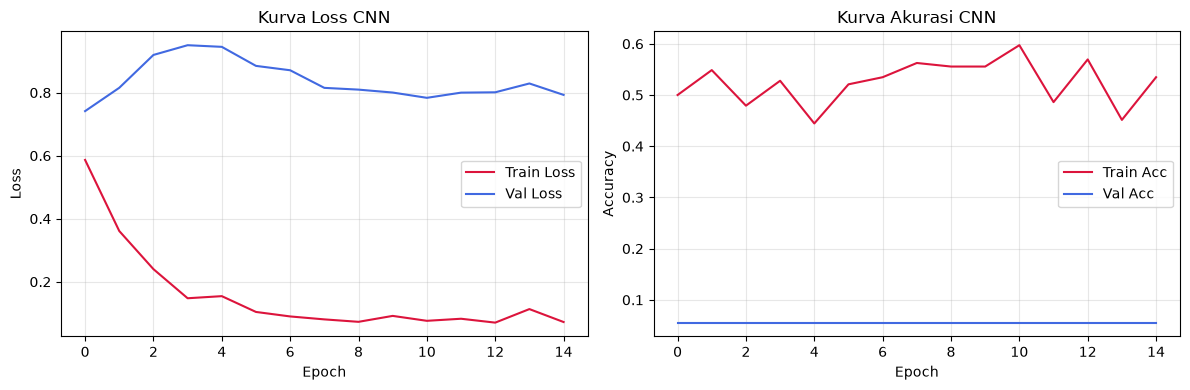

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='crimson')
axes[0].plot(history['val_loss'], label='Val Loss', color='royalblue')
axes[0].set_title('Kurva Loss CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='crimson')
axes[1].plot(history['val_acc'], label='Val Acc', color='royalblue')
axes[1].set_title('Kurva Akurasi CNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 2.7 Menyimpan Bobot Model CNN (.pth & TorchScript)

In [15]:
cnn_pth_path = os.path.join(MODEL_DIR, "cnn_mastitis_model.pth")
torch.save(cnn_model.state_dict(), cnn_pth_path)
print(f"Model PyTorch disimpan di: {cnn_pth_path}")

# Ekspor TorchScript untuk Android
try:
    cnn_model.eval()
    example_tensor = torch.rand(1, 3, 224, 224).to(DEVICE)
    traced_model = torch.jit.trace(cnn_model, example_tensor)
    ts_path = os.path.join(MODEL_DIR, "cnn_mastitis_model_traced.pt")
    traced_model.save(ts_path)
    print(f"Model TorchScript tersimpan di: {ts_path}")
except Exception as e:
    print(f"Warning export: {e}")

Model PyTorch disimpan di: c:\Users\ryuxy\PPL-AGRO\AI\models\cnn_mastitis_model.pth


C:\Users\ryuxy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\jit\_trace.py:1000: FutureWarning: `torch.jit.trace` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
C:\Users\ryuxy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\jit\_trace.py:1139: FutureWarning: `torch.jit.trace_method` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Model TorchScript tersimpan di: c:\Users\ryuxy\PPL-AGRO\AI\models\cnn_mastitis_model_traced.pt


--- 
## BAGIAN 3: PIPELINE INFERENSI TERPADU (PREDIKSI SIMULASI)

Sistem inferensi menggabungkan output probabilitas dari XGBoost (uji laboratorium/sensor susu) dan CNN (foto ambing peternak) untuk menghasilkan rekomendasi klinis akurat.

In [16]:
# Uji coba sampel susu baru
sample_milk = pd.DataFrame([{
    "Day": 21,
    "Milk_Temperature": 38.5,
    "Milk_pH": 7.2,
    "Milk_Conductivity": 6.8,
    "Somatic_Cell_Count": 650,
    "Milk_Yield": 9.5,
    "Clotting": 1
}])

prob_milk = xgb_model.predict_proba(sample_milk)[0][1]
pred_milk = xgb_model.predict(sample_milk)[0]

print("=== HASIL PREDIKSI SISTEM TERPADU ===")
print(f"Prediksi Sensor Susu (XGBoost) : {'MASTITIS' if pred_milk == 1 else 'SEHAT'}")
print(f"Tingkat Keyakinan Mastitis     : {prob_milk * 100:.2f}%")
if prob_milk >= 0.5:
    print("REKOMENDASI: Segera periksa ambing sapi secara visual, isolasi hasil perahan, dan lakukan pengobatan dini!")
else:
    print("REKOMENDASI: Kondisi susu normal dan higienis.")

=== HASIL PREDIKSI SISTEM TERPADU ===
Prediksi Sensor Susu (XGBoost) : MASTITIS
Tingkat Keyakinan Mastitis     : 99.78%
REKOMENDASI: Segera periksa ambing sapi secara visual, isolasi hasil perahan, dan lakukan pengobatan dini!
